In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

PROJECT_ROOT = Path("..").resolve()

possible_data_roots = [
    PROJECT_ROOT / "data" / "raw" / "state_farm",
    PROJECT_ROOT / "state-farm-distracted-driver-detection",
]

DATA_ROOT = None

for path in possible_data_roots:
    if (path / "driver_imgs_list.csv").exists():
        DATA_ROOT = path
        break

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find State Farm dataset folder.")

TRAIN_IMG_DIR = DATA_ROOT / "imgs" / "train"
CSV_PATH = DATA_ROOT / "driver_imgs_list.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATA_ROOT)
print("CSV exists:", CSV_PATH.exists())
print("Train folder exists:", TRAIN_IMG_DIR.exists())

Project root: D:\MSC_PROJECT
Dataset root: D:\MSC_PROJECT\state-farm-distracted-driver-detection
CSV exists: True
Train folder exists: True


In [2]:
df = pd.read_csv(CSV_PATH)

df["filepath"] = df.apply(
    lambda row: str(TRAIN_IMG_DIR / row["classname"] / row["img"]),
    axis=1
)

df["file_exists"] = df["filepath"].apply(lambda path: Path(path).exists())

df = df[df["file_exists"]].reset_index(drop=True)

CLASS_ORDER = [f"c{i}" for i in range(10)]
LABEL_MAP = {class_name: index for index, class_name in enumerate(CLASS_ORDER)}

df["label"] = df["classname"].map(LABEL_MAP)

print("Total images:", len(df))
print("Number of subjects:", df["subject"].nunique())
print("Number of classes:", df["classname"].nunique())

display(df.head())

Total images: 22424
Number of subjects: 26
Number of classes: 10


,subject,classname,img,filepath,file_exists,label
0,p002,c0,img_44733.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
1,p002,c0,img_72999.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
2,p002,c0,img_25094.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
3,p002,c0,img_69092.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0
4,p002,c0,img_92629.jpg,D:\MSC_PROJECT\state-farm-distracted-driver-de...,True,0


In [3]:
subjects = sorted(df["subject"].unique())

print("Subjects:")
print(subjects)

print("Total subjects:", len(subjects))

Subjects:
['p002', 'p012', 'p014', 'p015', 'p016', 'p021', 'p022', 'p024', 'p026', 'p035', 'p039', 'p041', 'p042', 'p045', 'p047', 'p049', 'p050', 'p051', 'p052', 'p056', 'p061', 'p064', 'p066', 'p072', 'p075', 'p081']
Total subjects: 26


In [4]:
SEED = 42

# First split: 70% train, 30% temporary set
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss1.split(df, groups=df["subject"])
)

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# Second split: temporary set into validation and test
gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(temp_df, groups=temp_df["subject"])
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("Train subjects:", train_df["subject"].nunique())
print("Validation subjects:", val_df["subject"].nunique())
print("Test subjects:", test_df["subject"].nunique())

Train images: 15899
Validation images: 3439
Test images: 3086
Train subjects: 18
Validation subjects: 4
Test subjects: 4


In [5]:
train_subjects = set(train_df["subject"])
val_subjects = set(val_df["subject"])
test_subjects = set(test_df["subject"])

train_val_overlap = train_subjects & val_subjects
train_test_overlap = train_subjects & test_subjects
val_test_overlap = val_subjects & test_subjects

print("Train-Val subject overlap:", train_val_overlap)
print("Train-Test subject overlap:", train_test_overlap)
print("Val-Test subject overlap:", val_test_overlap)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("Success: No subject leakage found.")

Train-Val subject overlap: set()
Train-Test subject overlap: set()
Val-Test subject overlap: set()
Success: No subject leakage found.


In [6]:
print("Train subjects:")
print(sorted(train_subjects))

print("\nValidation subjects:")
print(sorted(val_subjects))

print("\nTest subjects:")
print(sorted(test_subjects))

Train subjects:
['p014', 'p015', 'p016', 'p021', 'p022', 'p024', 'p039', 'p042', 'p047', 'p049', 'p051', 'p052', 'p056', 'p061', 'p064', 'p066', 'p072', 'p081']

Validation subjects:
['p026', 'p035', 'p041', 'p050']

Test subjects:
['p002', 'p012', 'p045', 'p075']


In [7]:
split_class_distribution = pd.DataFrame({
    "train": train_df["classname"].value_counts().sort_index(),
    "validation": val_df["classname"].value_counts().sort_index(),
    "test": test_df["classname"].value_counts().sort_index(),
}).fillna(0).astype(int)

display(split_class_distribution)

,train,validation,test
classname,,,
c0,1766,407,316
c1,1623,319,325
c2,1649,330,338
c3,1646,378,322
c4,1623,358,345
c5,1614,371,327
c6,1649,365,311
c7,1383,326,293
c8,1383,277,251


In [8]:
CLASS_NAMES = {
    "c0": "safe driving",
    "c1": "texting right",
    "c2": "talking on the phone right",
    "c3": "texting left",
    "c4": "talking on the phone left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger",
}

split_class_distribution_named = split_class_distribution.copy()
split_class_distribution_named.insert(
    0,
    "class_name",
    [CLASS_NAMES[class_id] for class_id in split_class_distribution_named.index]
)

display(split_class_distribution_named)

,class_name,train,validation,test
classname,,,,
c0,safe driving,1766,407,316
c1,texting right,1623,319,325
c2,talking on the phone right,1649,330,338
c3,texting left,1646,378,322
c4,talking on the phone left,1623,358,345
c5,operating the radio,1614,371,327
c6,drinking,1649,365,311
c7,reaching behind,1383,326,293
c8,hair and makeup,1383,277,251


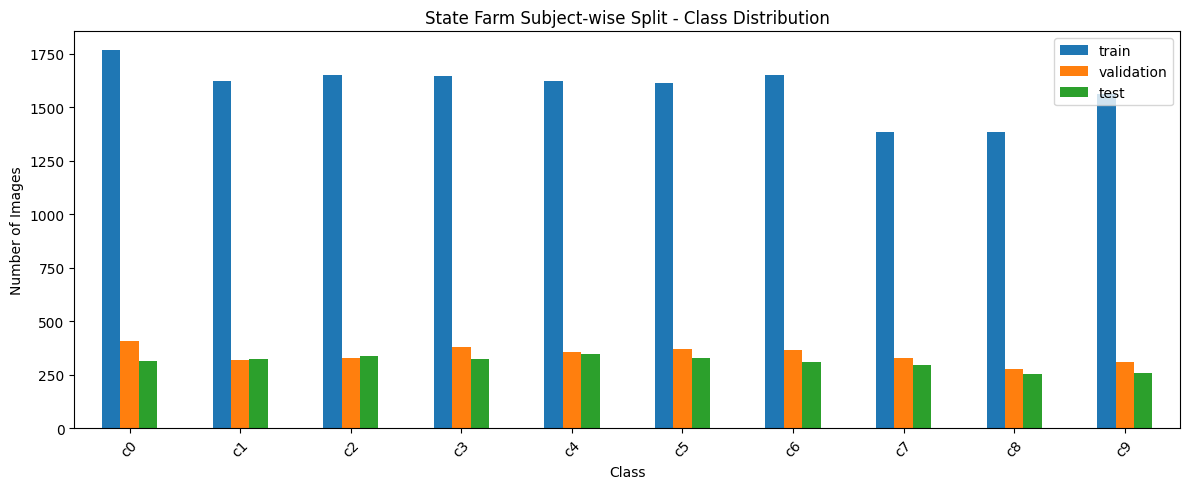

In [9]:
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

split_class_distribution.plot(kind="bar", figsize=(12, 5))

plt.title("State Farm Subject-wise Split - Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "state_farm_subject_wise_split_class_distribution.png", dpi=300)
plt.show()

In [10]:
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_path = SPLIT_DIR / "state_farm_train_subject.csv"
val_path = SPLIT_DIR / "state_farm_val_subject.csv"
test_path = SPLIT_DIR / "state_farm_test_subject.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved train split:", train_path)
print("Saved validation split:", val_path)
print("Saved test split:", test_path)

Saved train split: D:\MSC_PROJECT\data\splits\state_farm_train_subject.csv
Saved validation split: D:\MSC_PROJECT\data\splits\state_farm_val_subject.csv
Saved test split: D:\MSC_PROJECT\data\splits\state_farm_test_subject.csv


In [11]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "num_images": [len(train_df), len(val_df), len(test_df)],
    "num_subjects": [
        train_df["subject"].nunique(),
        val_df["subject"].nunique(),
        test_df["subject"].nunique()
    ],
    "subjects": [
        ", ".join(sorted(train_df["subject"].unique())),
        ", ".join(sorted(val_df["subject"].unique())),
        ", ".join(sorted(test_df["subject"].unique()))
    ]
})

display(split_summary)

split_summary.to_csv(
    TABLES_DIR / "state_farm_subject_wise_split_summary.csv",
    index=False
)

split_class_distribution_named.to_csv(
    TABLES_DIR / "state_farm_subject_wise_split_class_distribution.csv"
)

print("Saved split summary and class distribution tables.")

,split,num_images,num_subjects,subjects
0,train,15899,18,"p014, p015, p016, p021, p022, p024, p039, p042..."
1,validation,3439,4,"p026, p035, p041, p050"
2,test,3086,4,"p002, p012, p045, p075"


Saved split summary and class distribution tables.


**Subject Vs Class Evaluation**

In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "state-farm-distracted-driver-detection"

metadata_path = DATA_ROOT / "driver_imgs_list.csv"
df = pd.read_csv(metadata_path)

# Count how many unique classes each subject has
subject_class_count = (
    df.groupby("subject")["classname"]
    .nunique()
    .reset_index()
    .rename(columns={"classname": "number_of_classes"})
)

display(subject_class_count)

# Subjects that have all 10 classes
subjects_with_all_classes = subject_class_count[subject_class_count["number_of_classes"] == 10]

# Subjects missing at least one class
subjects_missing_classes = subject_class_count[subject_class_count["number_of_classes"] < 10]

print("Total subjects:", subject_class_count.shape[0])
print("Subjects with all 10 classes:", subjects_with_all_classes.shape[0])
print("Subjects missing one or more classes:", subjects_missing_classes.shape[0])

display(subjects_missing_classes)

,subject,number_of_classes
0,p002,10
1,p012,10
2,p014,10
3,p015,10
4,p016,10
5,p021,10
6,p022,10
7,p024,10
8,p026,10
9,p035,10


Total subjects: 26
Subjects with all 10 classes: 26
Subjects missing one or more classes: 0


,subject,number_of_classes


In [2]:
subject_class_table = pd.crosstab(df["subject"], df["classname"])

display(subject_class_table)

classname,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9
subject,,,,,,,,,,
p002,76,74,86,79,84,76,83,72,44,51
p012,84,95,91,89,97,96,75,72,62,62
p014,100,103,100,100,103,102,101,77,38,52
p015,79,85,88,94,101,101,99,81,86,61
p016,111,102,101,128,104,104,108,101,99,120
p021,135,131,127,128,132,130,126,98,99,131
p022,129,129,128,129,130,130,131,98,98,131
p024,130,129,128,130,129,131,129,101,99,120
p026,130,129,130,131,126,130,128,97,97,98


In [3]:
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"

train_df = pd.read_csv(SPLIT_DIR / "state_farm_train_subject.csv")
val_df = pd.read_csv(SPLIT_DIR / "state_farm_val_subject.csv")
test_df = pd.read_csv(SPLIT_DIR / "state_farm_test_subject.csv")

for split_name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print("\n", split_name)
    print("Number of subjects:", split_df["subject"].nunique())
    print("Classes present:", sorted(split_df["classname"].unique()))
    print("Number of classes:", split_df["classname"].nunique())


 Train
Number of subjects: 18
Classes present: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10

 Validation
Number of subjects: 4
Classes present: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10

 Test
Number of subjects: 4
Classes present: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10
